
Untuk mount ke google drive :



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Langkah-langkah path file drive:
1. Download dataset BungaDataSet di link ini
[Click Download BungaDataSet.zip](https://drive.google.com/file/d/16B8KTvL4f31sfy-U-hWOMIhoHn7CS-bp/view?usp=sharing
)
2. Upload ke foolder drive anda masing2 file.zip tsb
2. Sesuaikan path ke drive masing2, untuk ekstrak file tsb

    `from zipfile import ZipFile`

    `file_name ="/content/drive/MyDrive/BungaDataSet.zip"`

In [2]:
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/pola/BungaDataSet.zip"

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
print("Done")

Done


Data Training CNN

19324996661_4676b644e6_c.jpg
18836241343_fdc9408188_c.jpg
18768504329_689b0a168d_c.jpg
16594538760_b96b560155_c.jpg
17854372768_fa7794ce78_c.jpg
15313562241_ce0b9806c6_c.jpg
14963539571_fac79110c6_c.jpg
14973939731_a71af7c133_c.jpg
15072889691_483624bcdb_c.jpg
19922303732_566c83db36_c.jpg
19080471710_58d0044b7c_c.jpg
14933945383_ff20b1f1f8_c.jpg
18668745150_2a6ceeb314_c.jpg
15436028147_a62a187c2c_c.jpg
17821711772_0456b8ba31_c.jpg
19906312496_9d918be2a9_c.jpg
15329039410_ebb90c90f3_c.jpg
15591065106_4d2b462798_c.jpg
16091801268_8f2759444d_c.jpg
14995594331_157aa25987_c.jpg
18424437954_a770680191_c.jpg
19024878656_3e118633af_c.jpg
14736892537_11e3ebb94f_c.jpg
14948206667_53d275a1c8_c.jpg
19117971270_f1e722dc90_c.jpg
16899386455_a0bb659295_c.jpg
14800415418_a32dc140fe_c.jpg
15976535861_4ce6ef5481_c.jpg
14739829837_3b98b5f326_c.jpg
15129320988_0033487194_c.jpg
14911419152_1138bd1724_c.jpg
15685771949_8a2d6a7991_c.jpg
19145243085_d4fba7eca7_c.jpg
18968395745_278bbeabc1_c.jpg
17610894544_59

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,276,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │         1,414 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,923,420 (37.85 MB)

 Trainable params: 3,307,806 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,615,614 (25.24 MB)

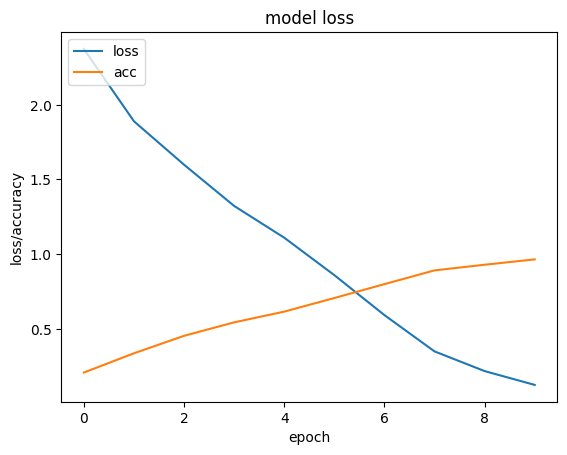

In [3]:
import os
from keras.models import load_model
import cv2
import numpy as np
from keras.layers import Input, Dense
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.models import Model
import matplotlib.pyplot as plt

def LoadCitraTraining(sDir,LabelKelas):
  JumlahKelas=len(LabelKelas)
  TargetKelas = np.eye(JumlahKelas)
# Menyiapkan variabel list untuk data menampung citra dan data target
  X=[]#Menampung Data Citra
  T=[]#Menampung Target
  for i in range(len(LabelKelas)):
    #Membaca file citra di setiap direktori data set
    DirKelas = os.path.join(sDir, LabelKelas[i])
    files = os.listdir(DirKelas)

    for f in files:
      ff=f.lower()
      print(f)
      #memilih citra dengan extensi jpg,jpeg,dan png
      if (ff.endswith('.jpg')|ff.endswith('.jpeg')|ff.endswith('.png')):
         NmFile = os.path.join(DirKelas,f)
         #membaca citra berwarna sebagai data bertipe double
         img= np.double(cv2.imread(NmFile,1))
         img=cv2.resize(img,(128,128));
         #Normalisasi data citra menjadi sehingga maksimum menjadi 1
         img= np.asarray(img)/255;
         img=img.astype('float32')
         #Menambahkan citra dan target ke daftar
         X.append(img)
         T.append(TargetKelas[i])
     #--------akhir loop :Pfor f in files-----------------
  #-----akhir  loop :for i in range(len(LabelKelas))----

  #Mengubah List Menjadi numppy array
  X=np.array(X)
  T=np.array(T)
  X=X.astype('float32')
  T=T.astype('float32')
  return X,T

def ModelDeepLearningCNN(JumlahKelas):
    input_img = Input(shape=(128, 128, 3))
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = Flatten()(x)
    x = Dense(100,activation='relu')(x)
    x = Dense(100,activation='relu')(x)
    x=Dense(JumlahKelas,activation='softmax')(x)
    ModelCNN = Model(input_img, x)
    ModelCNN.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    #ModelCNN.compile(loss='mse', optimizer='adam', metrics=['accuracy'])
    return ModelCNN

def TrainingCNN(JumlahEpoh,DirektoriDataSet,LabelKelas,NamaFileBobot ='weight.h5' ):
    #Membaca Data training dan label Kelas
    X,D=LoadCitraTraining(DirektoriDataSet,LabelKelas)
    JumlahKelas = len(LabelKelas)
    #Membuat Model CNN
    ModelCNN =ModelDeepLearningCNN(JumlahKelas)
    #Trainng
    history=ModelCNN.fit(X, D,epochs=JumlahEpoh,shuffle=True)
    #Menyimpan hasil learning
    ModelCNN.save(NamaFileBobot)
    #Mengembalikan output
    return ModelCNN,history


##########################################################
def Klasifikasi(DirDataSet,DirKlasifikasi,LabelKelas,ModelCNN=[]):
#Apabila parameter input ModelCNN tidak di isi maka
#   akan menggunakan bobot pada file 'weight.h5
  if not(ModelCNN):
      ModelCNN = load_model('weight.h5')

#Menyiapkan Data input Yang akan di kasifikasikan
  X=[]
  ls = [];
  DirKelas = DirDataSet+"\\"+DirKlasifikasi
  print(DirKelas)
  files = os.listdir(DirKelas)
  n=0;
  for f in files:
      ff=f.lower()
      print(f)
      if (ff.endswith('.jpg')|ff.endswith('.jpeg')|ff.endswith('.png')):
         ls.append(ff)
         NmFile = os.path.join(DirKelas,f)
         img= cv2.imread(NmFile,1)
         img=cv2.resize(img,(128,128))
         img= np.asarray(img)/255
         img=img.astype('float32')
         X.append(img)
     #----Akhir if-------------
  #---Akhir For
  X=np.array(X)
  X=X.astype('float32')
  #Melakukan prediksi Klasifikasi
  hs=ModelCNN.predict(X)

  LKlasifikasi=[];
  LKelasCitra =[];
  n = X.shape[0]
  for i in range(n):
      v=hs[i,:]
      if v.max()>0.5:
          idx = np.max(np.where( v == v.max()))
          LKelasCitra.append(LabelKelas[idx])
      else:
          idx=-1
          LKelasCitra.append("-")
      #------akhir if
      LKlasifikasi.append(idx);
  #----akhir for
  LKlasifikasi = np.array(LKlasifikasi)
  return ls, hs, LKelasCitra

#****************
#  Program Utama
#****************

###############################################
#  1, Training CNN
#----------------------------------------------
#a. Menentukan Direktori Yang menyimpan Data set
DirektoriDataSet="/content/BungaDataSet/train"
#   Data Set disimpan dalam direktori yang sama dengan nama kelas

#b. Label Data Set
LabelKelas=(
    "water_lily",
    "tulip",
    "sunflower",
    "rose",
    "iris",
    "dandelion",
    "coreopsis",
    "common_daisy",
    "carnation",
    "california_poppy",
    "calendula",
    "black_eyed_susan",
    "bellflower",
    "astilbe")

#c. Inisialisasi parameter Training
JumlahEpoh = 10;
FileBobot = "WRambu.h5"
#d. training
ModelCNN,history = TrainingCNN(JumlahEpoh,DirektoriDataSet,LabelKelas,FileBobot)
ModelCNN.summary()

#c. Menampilkan Grafik Loss dan accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])

plt.title('model loss')
plt.ylabel('loss/accuracy')
plt.xlabel('epoch')
plt.legend(['loss', 'acc'], loc='upper left')
plt.show()


Check Prediksi Tanpa Anvil

In [4]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

# Label kelas sesuai model yang sudah dilatih
LabelKelas = [
    "water_lily",
    "tulip",
    "sunflower",
    "rose",
    "iris",
    "dandelion",
    "coreopsis",
    "common_daisy",
    "carnation",
    "california_poppy",
    "calendula",
    "black_eyed_susan",
    "bellflower",
    "astilbe"]

uploaded = files.upload()

for fn in uploaded.keys():
  # Load dan tampilkan gambar
  path = fn
  img = image.load_img(path, target_size=(128, 128))
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  # Pra-pemrosesan citra
  x = image.img_to_array(img)
  x = x / 255.0  # normalisasi
  x = np.expand_dims(x, axis=0)

  # Prediksi
  classes = ModelCNN.predict(x)
  pred_idx = np.argmax(classes[0])
  pred_label = LabelKelas[pred_idx]

  print(f'{fn} => Predicted jenis bunga: {pred_label}')

Untuk Install Anvil

In [5]:
!pip install anvil-uplink

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.9/97.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.3 MB/s eta 0:00:00


Masukan library anvil

In [6]:
import anvil.server

Langkah upload token server
1. Click tombol tambah, setelah memasukan semua design dan code di anvil
2. Click tombool Uplink , lalu salin server token uplink. Gunakan token server di anvil mu sendiri
3. Gunakan di sini ```anvil.server.connect("server_")```



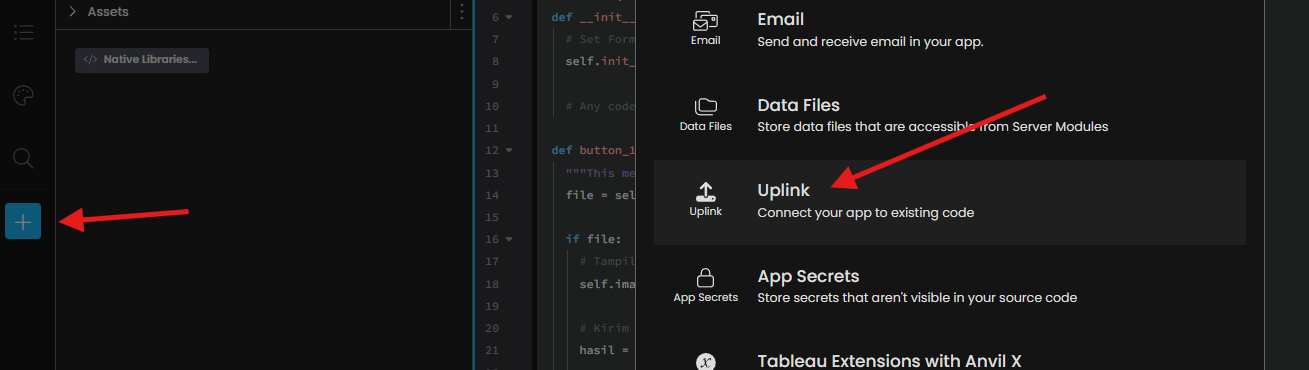

In [7]:
anvil.server.connect("server_QVKHMYIQXU5V3LGB53IS7MOU-WSVDQM3BD5GU4NIM")

Connecting to wss://anvil.works/uplink
Anvil websocket open
Connected to "Published" as SERVER


Method/function pemanggilan dari anvil gui

In [8]:
import anvil.server
import anvil.media
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np



ModelCNN = load_model('WRambu.h5')

# Label kelas sesuai urutan output model
LabelKelas = [
    "water_lily",
    "tulip",
    "sunflower",
    "rose",
    "iris",
    "dandelion",
    "coreopsis",
    "common_daisy",
    "carnation",
    "california_poppy",
    "calendula",
    "black_eyed_susan",
    "bellflower",
    "astilbe"]

@anvil.server.callable
def classify_image(file):
    with anvil.media.TempFile(file) as f:
        img = load_img(f, target_size=(128, 128))  # Sesuaikan jika model pakai ukuran lain
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        prediction = ModelCNN.predict(img_array)
        pred_index = np.argmax(prediction[0])
        pred_label = LabelKelas[pred_index]

        return pred_label


Colab server side, untuk hubungkan ke anvil
- jalankan ini terlebih dahulu sebelum run ke anvil

In [ ]:
anvil.server.wait_forever()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

#Langkah Lanjutan
[Click sini ke anvil.work](https://anvil.works/)
1. Copy dan paste ke code di anvil Codingan untuk anvil

```
# Silahkan copy dan paste ke anvil

from ._anvil_designer import Form1Template
from anvil import *
import anvil.server

class Form1(Form1Template):
  def __init__(self, **properties):
    # Set Form properties and Data Bindings.
    self.init_components(**properties)

    # Any code you write here will run before the form opens.

  def button_1_click(self, **event_args):
    """This method is called when the button is clicked"""
    file = self.file_loader_1.file

    if file:
      # Tampilkan gambar di preview
      self.image_1.source = file

      # Kirim ke server dan dapatkan hasil
      hasil = anvil.server.call('classify_image', file)

      # Tampilkan hasil prediksi
      self.label_1.text = f"NAMA BUNGA: {hasil.upper()}"
    else:
      self.label_1.text = "Silakan unggah gambar terlebih dahulu."

    pass
  def file_loader_1_change(self, file, **event_args):
    """This method is called when a new file is loaded into this FileLoader"""
    pass
```

2. edit tampilan anvil seperti ini
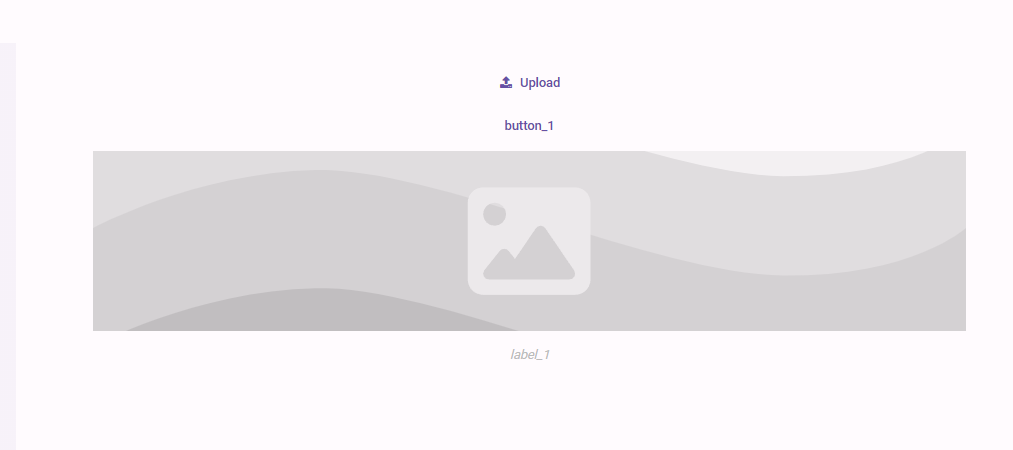